# Exercise 1

In [ ]:
from sklearn.datasets import load_wine
import pandas as pd

wine_data = load_wine()
X = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
y = wine_data.target

print(X.head())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0                  

In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

k = 5
nbrs = NearestNeighbors(n_neighbors=k)
nbrs.fit(X)

distances, indices = nbrs.kneighbors(X)

kth_distances = distances[:, -1]

In [ ]:
threshold = np.mean(kth_distances) + 2 * np.std(kth_distances)
anomalies = X[kth_distances > threshold]

print("Detected anomalies:")
print(anomalies)

Detected anomalies:
    alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
3     14.37        1.95  2.50               16.8      113.0           3.85   
5     14.20        1.76  2.45               15.2      112.0           3.27   
14    14.38        1.87  2.38               12.0      102.0           3.30   
18    14.19        1.59  2.48               16.5      108.0           3.30   
31    13.58        1.66  2.36               19.1      106.0           2.86   
53    13.77        1.90  2.68               17.1      115.0           3.00   
95    12.47        1.52  2.20               19.0      162.0           2.50   

    flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
3         3.49                  0.24             2.18             7.80  0.86   
5         3.39                  0.34             1.97             6.75  1.05   
14        3.64                  0.29             2.96             7.50  1.20   
18        3.93                  0.3

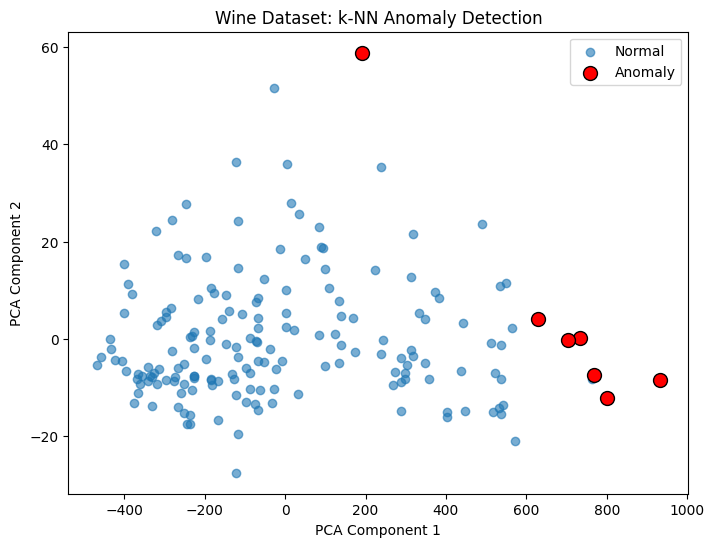

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], label='Normal', alpha=0.6)
plt.scatter(X_pca[kth_distances > threshold, 0],
            X_pca[kth_distances > threshold, 1],
            color='red', label='Anomaly', edgecolor='black', s=100)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Wine Dataset: k-NN Anomaly Detection')
plt.legend()
plt.show()

# Exercise 2

In [ ]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

cancer_data = load_breast_cancer()
X = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
y = cancer_data.target

print(X.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

k = 5
nbrs = NearestNeighbors(n_neighbors=k)
nbrs.fit(X)

distances, indices = nbrs.kneighbors(X)

kth_distances = distances[:, -1]

In [ ]:
threshold = np.mean(kth_distances) + 2 * np.std(kth_distances)
anomalies = X[kth_distances > threshold]

print(f"Number of anomalies detected: {len(anomalies)}")
print(anomalies)

Number of anomalies detected: 20
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
18         19.81         22.15           130.0     1260.0          0.09831   
23         21.16         23.04           137.2     1404.0          0.09428   
24         16.65         21.38           110.0      904.6          0.11210   
82         25.22         24.91           171.5     1878.0          0.10630   
108        22.27         19.67           152.8     1509.0          0.13260   
122        24.25         20.20           166.2     1761.0          0.14470   
164        23.27         22.04           152.1     1686.0          0.08439   
180        27.22         21.87           182.1     2250.0          0.10940   
202        23.29         26.67           158.9     1685.0          0.11410   
212        28.11         18.47           188.5     2499.0          0.11420   
219        19.53         32.47           128.0     1223.0          0.08420   
236        23.21         26.97 

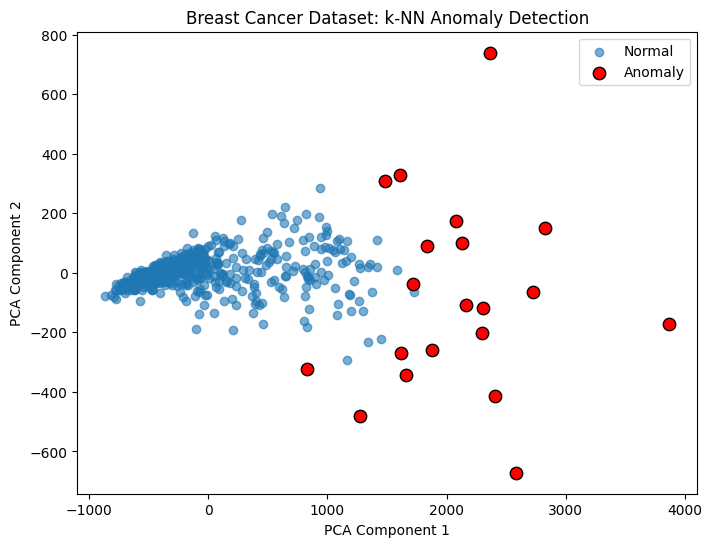

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], label='Normal', alpha=0.6)
plt.scatter(X_pca[kth_distances > threshold, 0],
            X_pca[kth_distances > threshold, 1],
            color='red', label='Anomaly', edgecolor='black', s=80)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Breast Cancer Dataset: k-NN Anomaly Detection')
plt.legend()
plt.show()